# 🍷 Wine Quality: Complete Machine Learning Project

**Dataset:** Red Wine Quality (UCI / Kaggle)  
**Goal:** Predict whether a wine is *GOOD* (quality ≥ 7) or *BAD* (quality < 7)  

**Workflow:**
1. Load & Explore Data
2. Missing-Value Check & Correlation Analysis
3. Feature Engineering: Binary Target
4. Baseline Logistic Regression (no scaling)
5. Logistic Regression with StandardScaler
6. Model Comparison: Logistic Regression vs KNN vs Decision Tree
7. Hyperparameter Tuning with GridSearchCV
8. Feature Importance Analysis

## 1 · Setup & Imports

In [23]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('All libraries loaded ✓')

All libraries loaded ✓


## 2 · Load Dataset

In [ ]:
df = pd.read_csv('winequality.csv')          # rename to match your file

print(f'Dataset shape: {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')

Dataset shape: (1599, 12)  (1599 rows × 12 columns)


## 3 · Basic Data Exploration

In [25]:
print('── First 5 rows ──────────────────────────────────────────────────────')
df.head()

── First 5 rows ──────────────────────────────────────────────────────


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [26]:
print('── DataFrame Info ────────────────────────────────────────────────────')
df.info()

── DataFrame Info ────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [27]:
print('── Statistical Summary ───────────────────────────────────────────────')
df.describe().round(3)

── Statistical Summary ───────────────────────────────────────────────


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


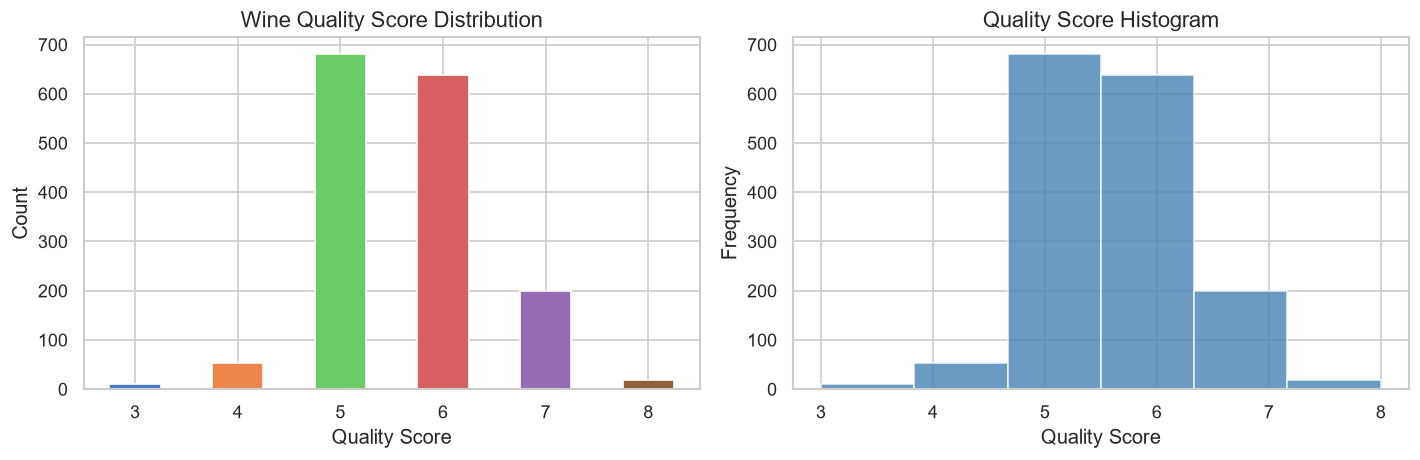

In [28]:
# Quality score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=sns.color_palette('muted', 6),
    edgecolor='white', rot=0
)
axes[0].set_title('Wine Quality Score Distribution')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

df['quality'].plot(kind='hist', bins=6, ax=axes[1], color='steelblue',
                   edgecolor='white', alpha=0.8)
axes[1].set_title('Quality Score Histogram')
axes[1].set_xlabel('Quality Score')

plt.tight_layout()
plt.show()

## 4 · Missing Values & Correlation Analysis

In [29]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing cells: {missing.sum()}')

if missing.sum() == 0:
    print('\n✅ No missing values – dataset is clean!')
else:
    print('\n⚠️  Missing values found – consider imputation.')

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing cells: 0

✅ No missing values – dataset is clean!


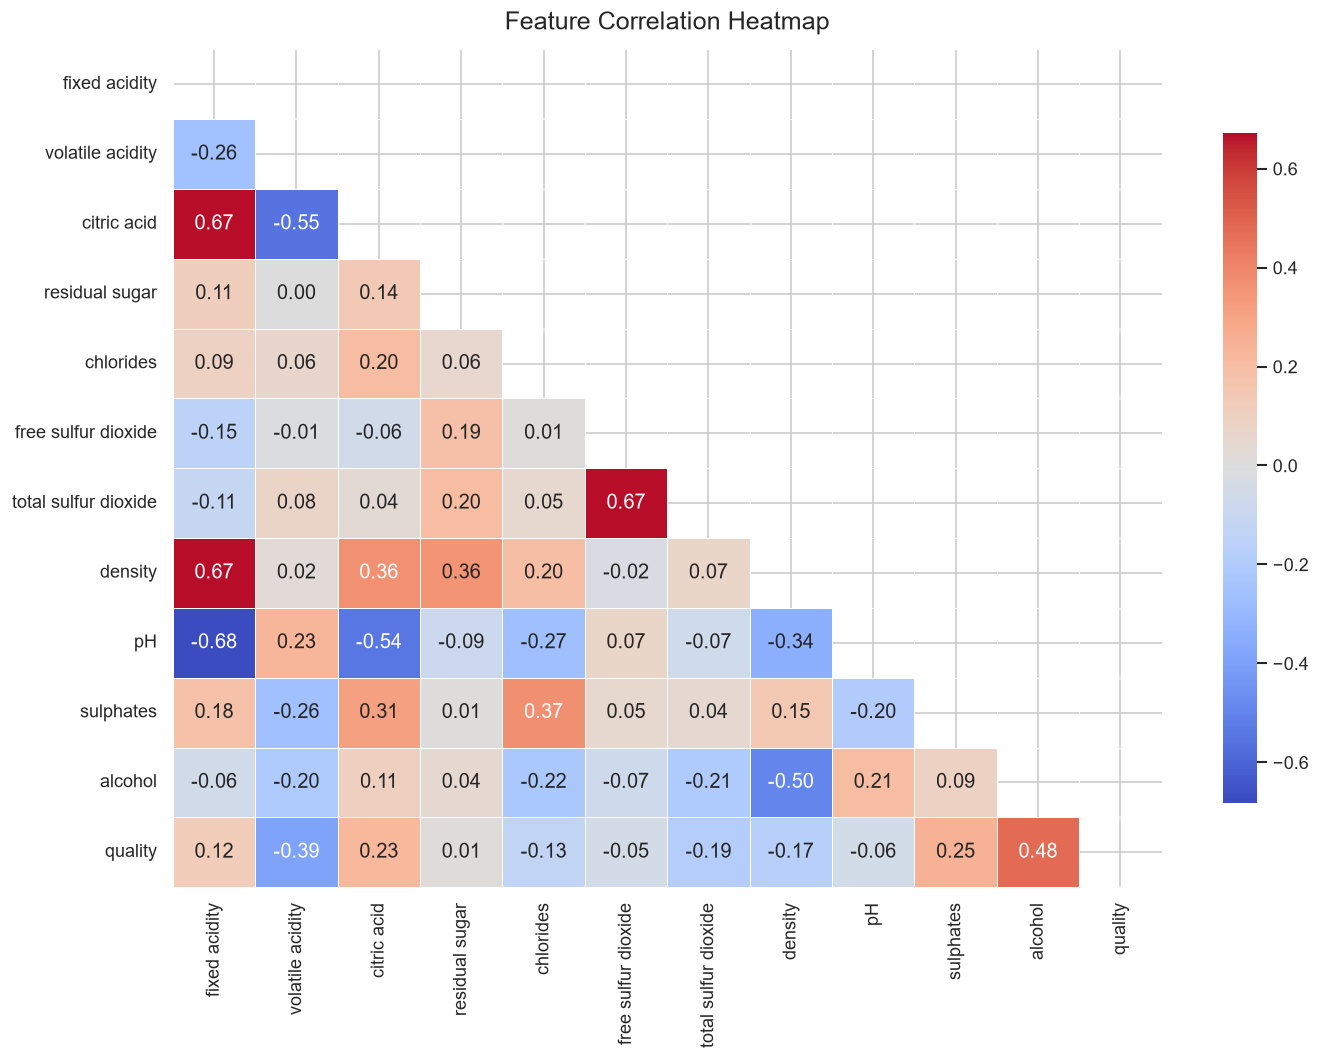

In [30]:
# Full correlation heatmap
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=15, pad=12)
plt.tight_layout()
plt.show()

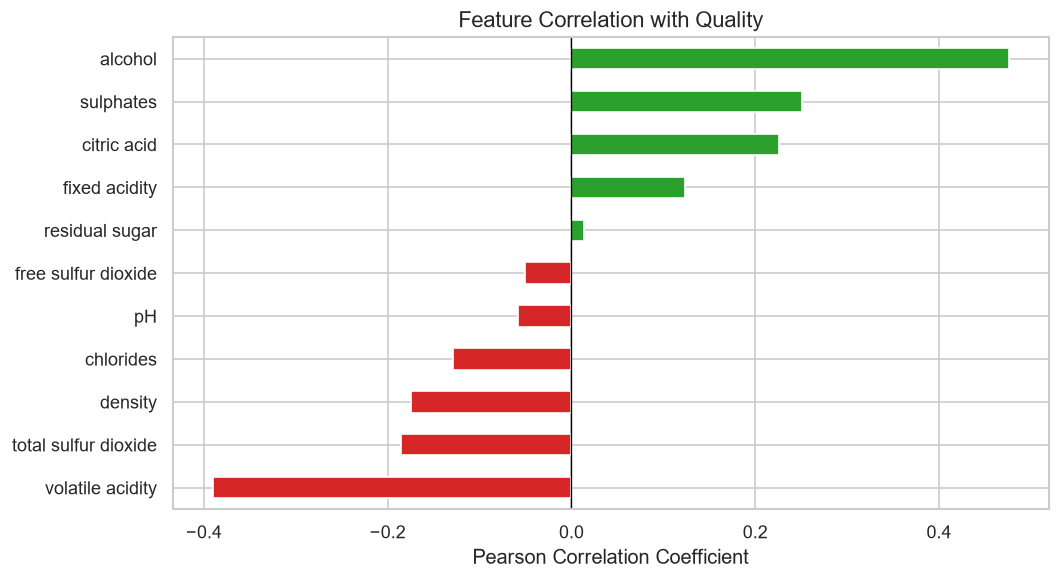


Top positive correlators: ['citric acid', 'sulphates', 'alcohol']
Top negative correlators: ['volatile acidity', 'total sulfur dioxide', 'density']


In [31]:
# Correlation with quality target only
quality_corr = corr['quality'].drop('quality').sort_values(ascending=True)

colors = ['#d62728' if v < 0 else '#2ca02c' for v in quality_corr]
quality_corr.plot(kind='barh', figsize=(9, 5), color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Quality')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print('\nTop positive correlators:', quality_corr[quality_corr > 0].tail(3).index.tolist())
print('Top negative correlators:', quality_corr[quality_corr < 0].head(3).index.tolist())

## 5 · Feature Engineering: Binary Target

Binary label distribution:
  BAD  (0):  1382  (86.4%)
  GOOD (1):   217  (13.6%)


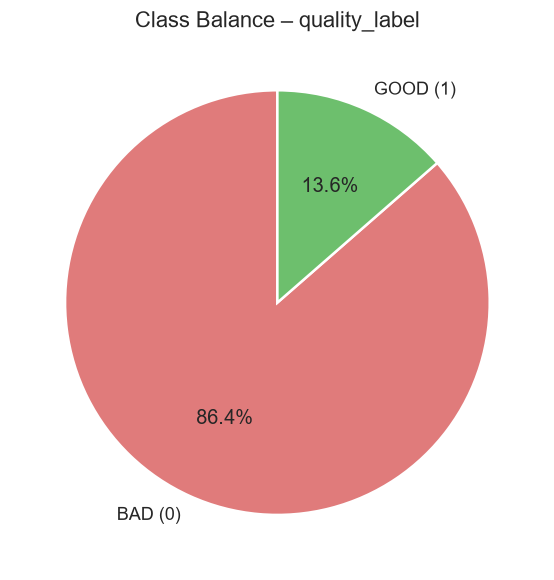

In [32]:
# quality >= 7  →  GOOD (1)  |  quality < 7  →  BAD (0)
df['quality_label'] = (df['quality'] >= 7).astype(int)

label_counts = df['quality_label'].value_counts()
print('Binary label distribution:')
print(f"  BAD  (0): {label_counts[0]:>5}  ({label_counts[0]/len(df)*100:.1f}%)")
print(f"  GOOD (1): {label_counts[1]:>5}  ({label_counts[1]/len(df)*100:.1f}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    label_counts, labels=['BAD (0)', 'GOOD (1)'],
    colors=['#e07b7b', '#6dbf6d'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Class Balance – quality_label', fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Train-Test Split

In [33]:
FEATURES = [c for c in df.columns if c not in ['quality', 'quality_label']]
TARGET   = 'quality_label'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features  : {FEATURES}')
print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')
print(f'Train positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  positives: {y_test.sum()}  ({y_test.mean()*100:.1f}%)')

Features  : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Train size: (1279, 11)  |  Test size: (320, 11)
Train positives: 174 (13.6%)
Test  positives: 43  (13.4%)


## 7 · Logistic Regression: Without Scaling (Baseline)

> Features are on very different scales (e.g. `total sulfur dioxide` can be 289 while `citric acid` is ≤ 1).  
> We train first **without scaling** to see how much that matters.

═══════════════════════════════════════════════════════
  Logistic Regression (No Scaling)
───────────────────────────────────────────────────────
  Accuracy : 0.8938
  Precision: 0.7368
  Recall   : 0.3256
  F1-Score : 0.4516
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     BAD (0)       0.90      0.98      0.94       277
    GOOD (1)       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320



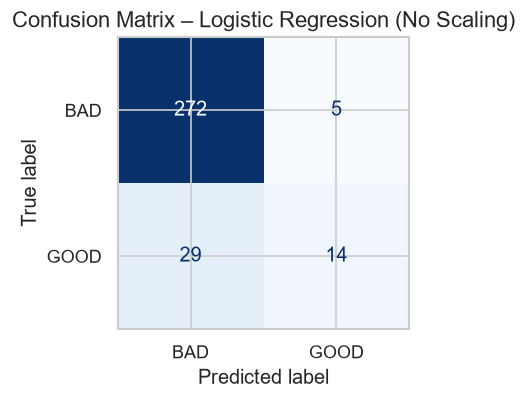

In [34]:
def evaluate(model, X_tr, y_tr, X_te, y_te, title='Model'):
    """Fit, predict, and print a full evaluation report."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f'{'═'*55}')
    print(f'  {title}')
    print(f'{'─'*55}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'{'─'*55}')
    print(classification_report(y_te, y_pred,
                                 target_names=['BAD (0)', 'GOOD (1)']))

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ConfusionMatrixDisplay(cm, display_labels=['BAD', 'GOOD']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Confusion Matrix – {title}')
    plt.tight_layout()
    plt.show()

    return {'model': title, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}


lr_noscale = LogisticRegression(max_iter=1000, random_state=42)
res_lr_noscale = evaluate(lr_noscale, X_train, y_train, X_test, y_test,
                          title='Logistic Regression (No Scaling)')

## 8 · Logistic Regression: With StandardScaler

> **StandardScaler** transforms each feature to mean=0, std=1.  
> Logistic Regression relies on gradient-based optimisation – scaling usually speeds convergence and can improve accuracy.

═══════════════════════════════════════════════════════
  Logistic Regression (StandardScaler)
───────────────────────────────────────────────────────
  Accuracy : 0.8938
  Precision: 0.6957
  Recall   : 0.3721
  F1-Score : 0.4848
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     BAD (0)       0.91      0.97      0.94       277
    GOOD (1)       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



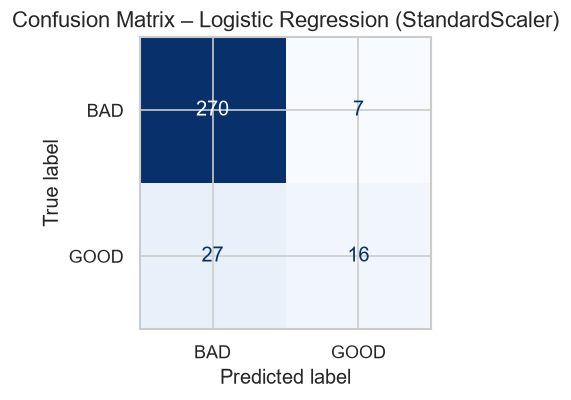

In [35]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = scaler.transform(X_test)         # transform test (no fit!)

lr_scaled = LogisticRegression(max_iter=1000, random_state=42)
res_lr_scaled = evaluate(lr_scaled, X_train_sc, y_train, X_test_sc, y_test,
                         title='Logistic Regression (StandardScaler)')

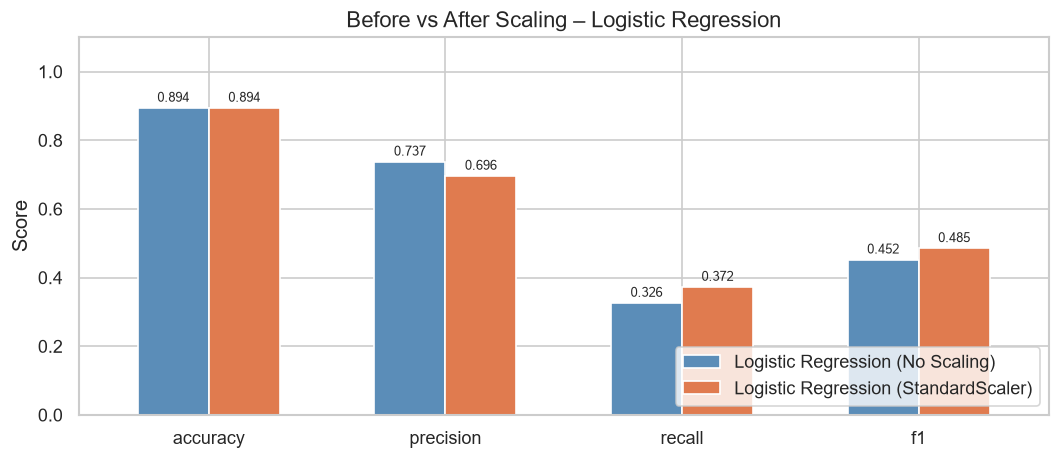

                                      accuracy  precision  recall      f1
model                                                                    
Logistic Regression (No Scaling)        0.8938     0.7368  0.3256  0.4516
Logistic Regression (StandardScaler)    0.8938     0.6957  0.3721  0.4848


In [36]:
# Side-by-side comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
comp_df = pd.DataFrame([res_lr_noscale, res_lr_scaled]).set_index('model')[metrics]

ax = comp_df.T.plot(kind='bar', figsize=(9, 4), rot=0,
                    color=['#5b8db8', '#e07b4f'], edgecolor='white', width=0.6)
ax.set_ylim(0, 1.1)
ax.set_title('Before vs After Scaling – Logistic Regression', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print(comp_df.round(4).to_string())

## 9 · Model Comparison: Logistic Regression vs KNN vs Decision Tree

═══════════════════════════════════════════════════════
  Logistic Regression
───────────────────────────────────────────────────────
  Accuracy : 0.8938
  Precision: 0.6957
  Recall   : 0.3721
  F1-Score : 0.4848
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     BAD (0)       0.91      0.97      0.94       277
    GOOD (1)       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



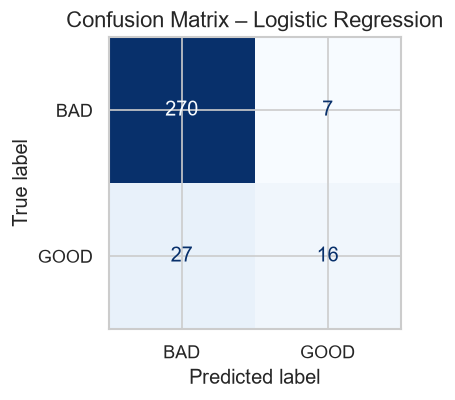

═══════════════════════════════════════════════════════
  K-Nearest Neighbours
───────────────────────────────────────────────────────
  Accuracy : 0.8938
  Precision: 0.6667
  Recall   : 0.4186
  F1-Score : 0.5143
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     BAD (0)       0.91      0.97      0.94       277
    GOOD (1)       0.67      0.42      0.51        43

    accuracy                           0.89       320
   macro avg       0.79      0.69      0.73       320
weighted avg       0.88      0.89      0.88       320



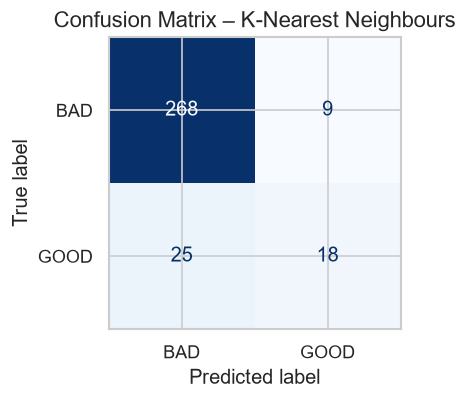

═══════════════════════════════════════════════════════
  Decision Tree
───────────────────────────────────────────────────────
  Accuracy : 0.9062
  Precision: 0.6383
  Recall   : 0.6977
  F1-Score : 0.6667
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     BAD (0)       0.95      0.94      0.95       277
    GOOD (1)       0.64      0.70      0.67        43

    accuracy                           0.91       320
   macro avg       0.80      0.82      0.81       320
weighted avg       0.91      0.91      0.91       320



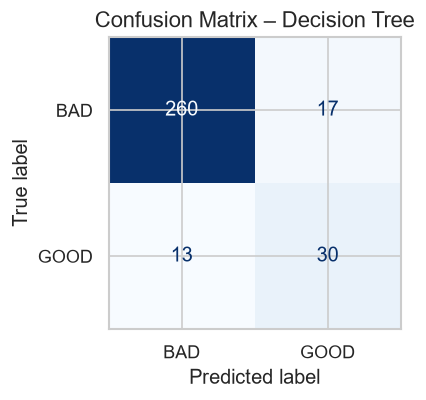


── Summary Table ──────────────────────────────────────────────
                      accuracy  precision  recall      f1
model                                                    
Logistic Regression     0.8938     0.6957  0.3721  0.4848
K-Nearest Neighbours    0.8938     0.6667  0.4186  0.5143
Decision Tree           0.9062     0.6383  0.6977  0.6667


In [37]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

results = []
for name, model in models.items():
    # All models trained on scaled data for a fair comparison
    r = evaluate(model, X_train_sc, y_train, X_test_sc, y_test, title=name)
    results.append(r)

results_df = pd.DataFrame(results).set_index('model')
print('\n── Summary Table ──────────────────────────────────────────────')
print(results_df.round(4).to_string())

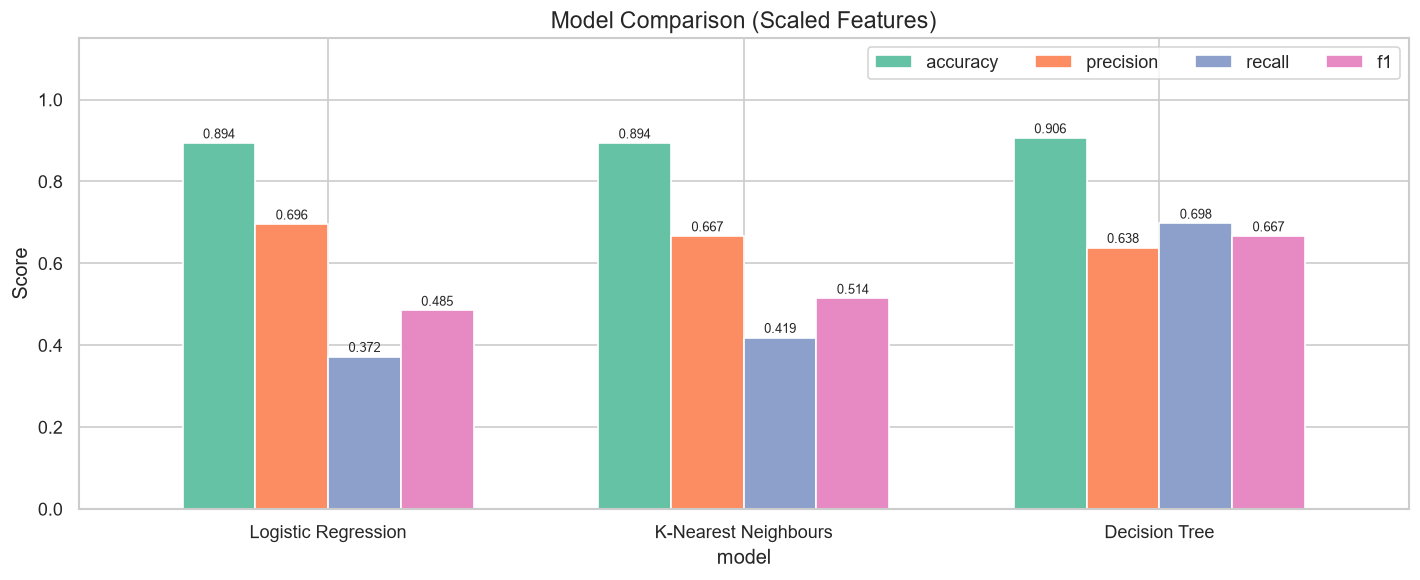


🏆 Best model by F1-Score: Decision Tree  (F1 = 0.6667)


In [38]:
# Grouped bar chart
metrics_plot = ['accuracy', 'precision', 'recall', 'f1']
ax = results_df[metrics_plot].plot(
    kind='bar', figsize=(12, 5), rot=0,
    color=sns.color_palette('Set2', 4),
    edgecolor='white', width=0.7
)
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison (Scaled Features)', fontsize=14)
ax.set_ylabel('Score')
ax.legend(loc='upper right', ncol=4)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.005),
                ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.show()

best_model_name = results_df['f1'].idxmax()
print(f'\n🏆 Best model by F1-Score: {best_model_name}  '
      f'(F1 = {results_df.loc[best_model_name, "f1"]:.4f})')

## 10 · Hyperparameter Tuning with GridSearchCV

> We tune whichever model won the comparison above.  
> Grids are defined for all three so you can re-run after changing `best_model_name`.

In [39]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2']
    },
    'K-Nearest Neighbours': {
        'n_neighbors': [3, 5, 7, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }
}

estimator_classes = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

estimator = estimator_classes[best_model_name]
grid      = param_grids[best_model_name]

print(f'Running GridSearchCV for: {best_model_name}')
print(f'Parameter grid: {grid}')

gs = GridSearchCV(
    estimator, grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
gs.fit(X_train_sc, y_train)

print(f'\n✅ Best params : {gs.best_params_}')
print(f'   Best CV F1  : {gs.best_score_:.4f}')

Running GridSearchCV for: Decision Tree
Parameter grid: {'max_depth': [None, 5, 10, 15, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy']}
Fitting 5 folds for each of 90 candidates, totalling 450 fits

✅ Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Best CV F1  : 0.5274


═══════════════════════════════════════════════════════
  Decision Tree (Tuned)
───────────────────────────────────────────────────────
  Accuracy : 0.9250
  Precision: 0.7317
  Recall   : 0.6977
  F1-Score : 0.7143
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     BAD (0)       0.95      0.96      0.96       277
    GOOD (1)       0.73      0.70      0.71        43

    accuracy                           0.93       320
   macro avg       0.84      0.83      0.84       320
weighted avg       0.92      0.93      0.92       320



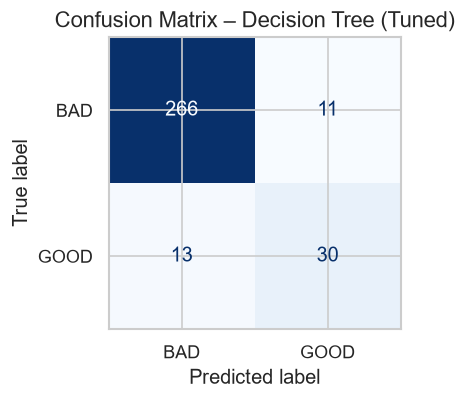

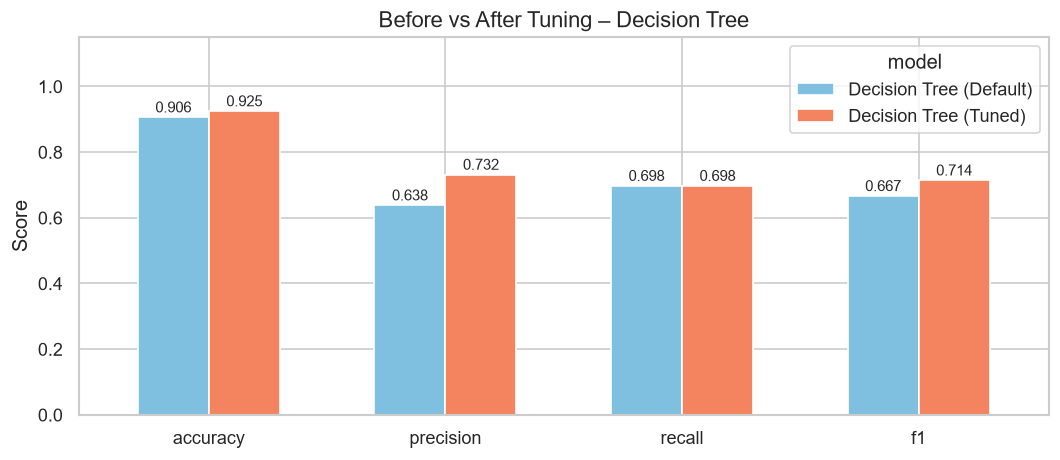

In [40]:
# Evaluate tuned model on held-out test set
best_tuned = gs.best_estimator_
res_tuned  = evaluate(best_tuned, X_train_sc, y_train, X_test_sc, y_test,
                      title=f'{best_model_name} (Tuned)')

# Before vs After tuning
before = results_df.loc[best_model_name].to_dict()
before['model'] = f'{best_model_name} (Default)'
after  = res_tuned

tune_df = pd.DataFrame([before, after]).set_index('model')[metrics_plot]
ax = tune_df.T.plot(kind='bar', figsize=(9, 4), rot=0,
                    color=['#7fbfdf', '#f4845f'], edgecolor='white', width=0.6)
ax.set_ylim(0, 1.15)
ax.set_title(f'Before vs After Tuning – {best_model_name}', fontsize=13)
ax.set_ylabel('Score')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.005),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 11 · Feature Importance Analysis

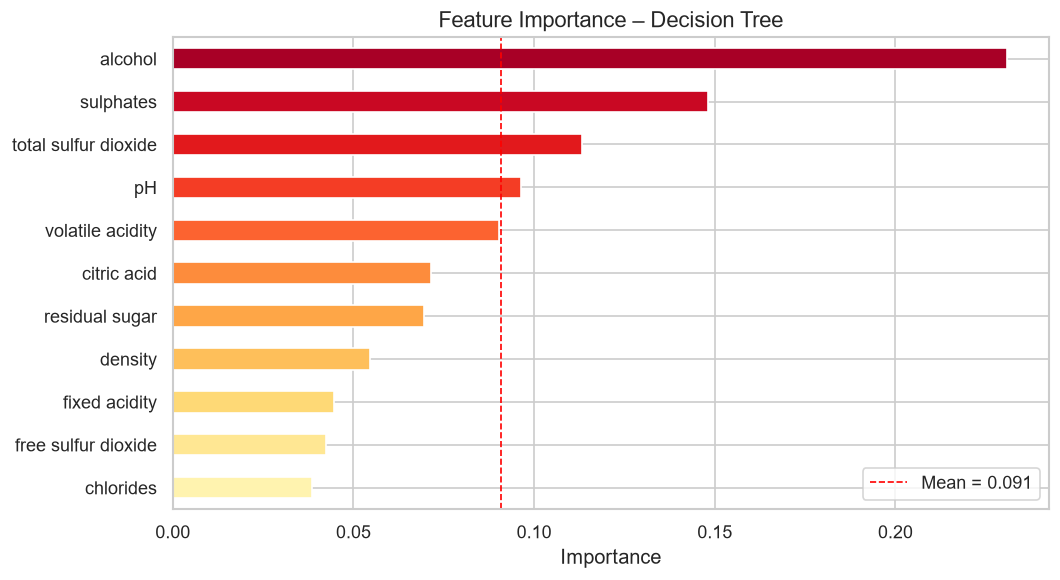

Decision Tree Feature Ranking:
alcohol                 0.2309
sulphates               0.1480
total sulfur dioxide    0.1133
pH                      0.0965
volatile acidity        0.0902
citric acid             0.0714
residual sugar          0.0696
density                 0.0546
fixed acidity           0.0447
free sulfur dioxide     0.0424
chlorides               0.0385


In [41]:
# ── Strategy: use the best-tuned model if it exposes coefficients or
#    feature_importances_; otherwise fall back to a fresh Decision Tree.

def plot_feature_importance(importances, feature_names, title):
    fi = pd.Series(np.abs(importances), index=feature_names)
    fi = fi.sort_values(ascending=True)

    colors = sns.color_palette('YlOrRd', len(fi))
    fig, ax = plt.subplots(figsize=(9, 5))
    fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Importance (absolute value)' if 'coeff' in title.lower() else 'Importance')
    ax.axvline(fi.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean = {fi.mean():.3f}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fi.sort_values(ascending=False)


# Decision Tree importance (always available)
dt_fi = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_fi.fit(X_train_sc, y_train)
fi_dt = plot_feature_importance(
    dt_fi.feature_importances_, FEATURES,
    'Feature Importance – Decision Tree'
)
print('Decision Tree Feature Ranking:')
print(fi_dt.round(4).to_string())

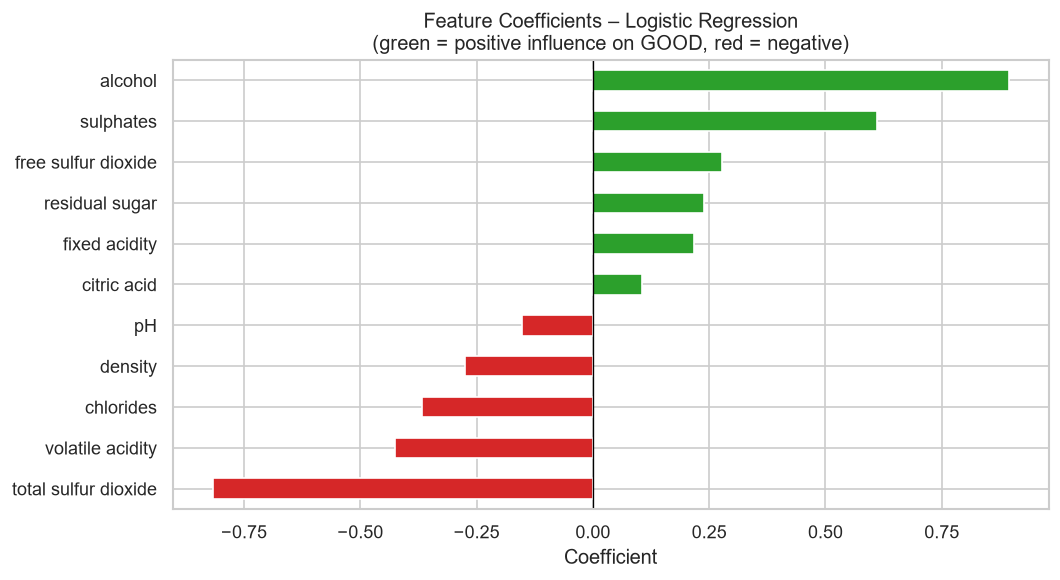

Top features pushing toward GOOD (1):
alcohol                0.8944
sulphates              0.6111
free sulfur dioxide    0.2773
residual sugar         0.2387
fixed acidity          0.2177
citric acid            0.1054

Top features pushing toward BAD (0):
total sulfur dioxide   -0.8174
volatile acidity       -0.4257
chlorides              -0.3678
density                -0.2755
pH                     -0.1517


In [42]:
# Logistic Regression coefficients (directional importance)
lr_fi = LogisticRegression(max_iter=1000, C=1, random_state=42)
lr_fi.fit(X_train_sc, y_train)

coeff = pd.Series(lr_fi.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in coeff]
coeff.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients – Logistic Regression\n(green = positive influence on GOOD, red = negative)', fontsize=12)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print('Top features pushing toward GOOD (1):')
print(coeff[coeff > 0].sort_values(ascending=False).round(4).to_string())
print('\nTop features pushing toward BAD (0):')
print(coeff[coeff < 0].sort_values().round(4).to_string())

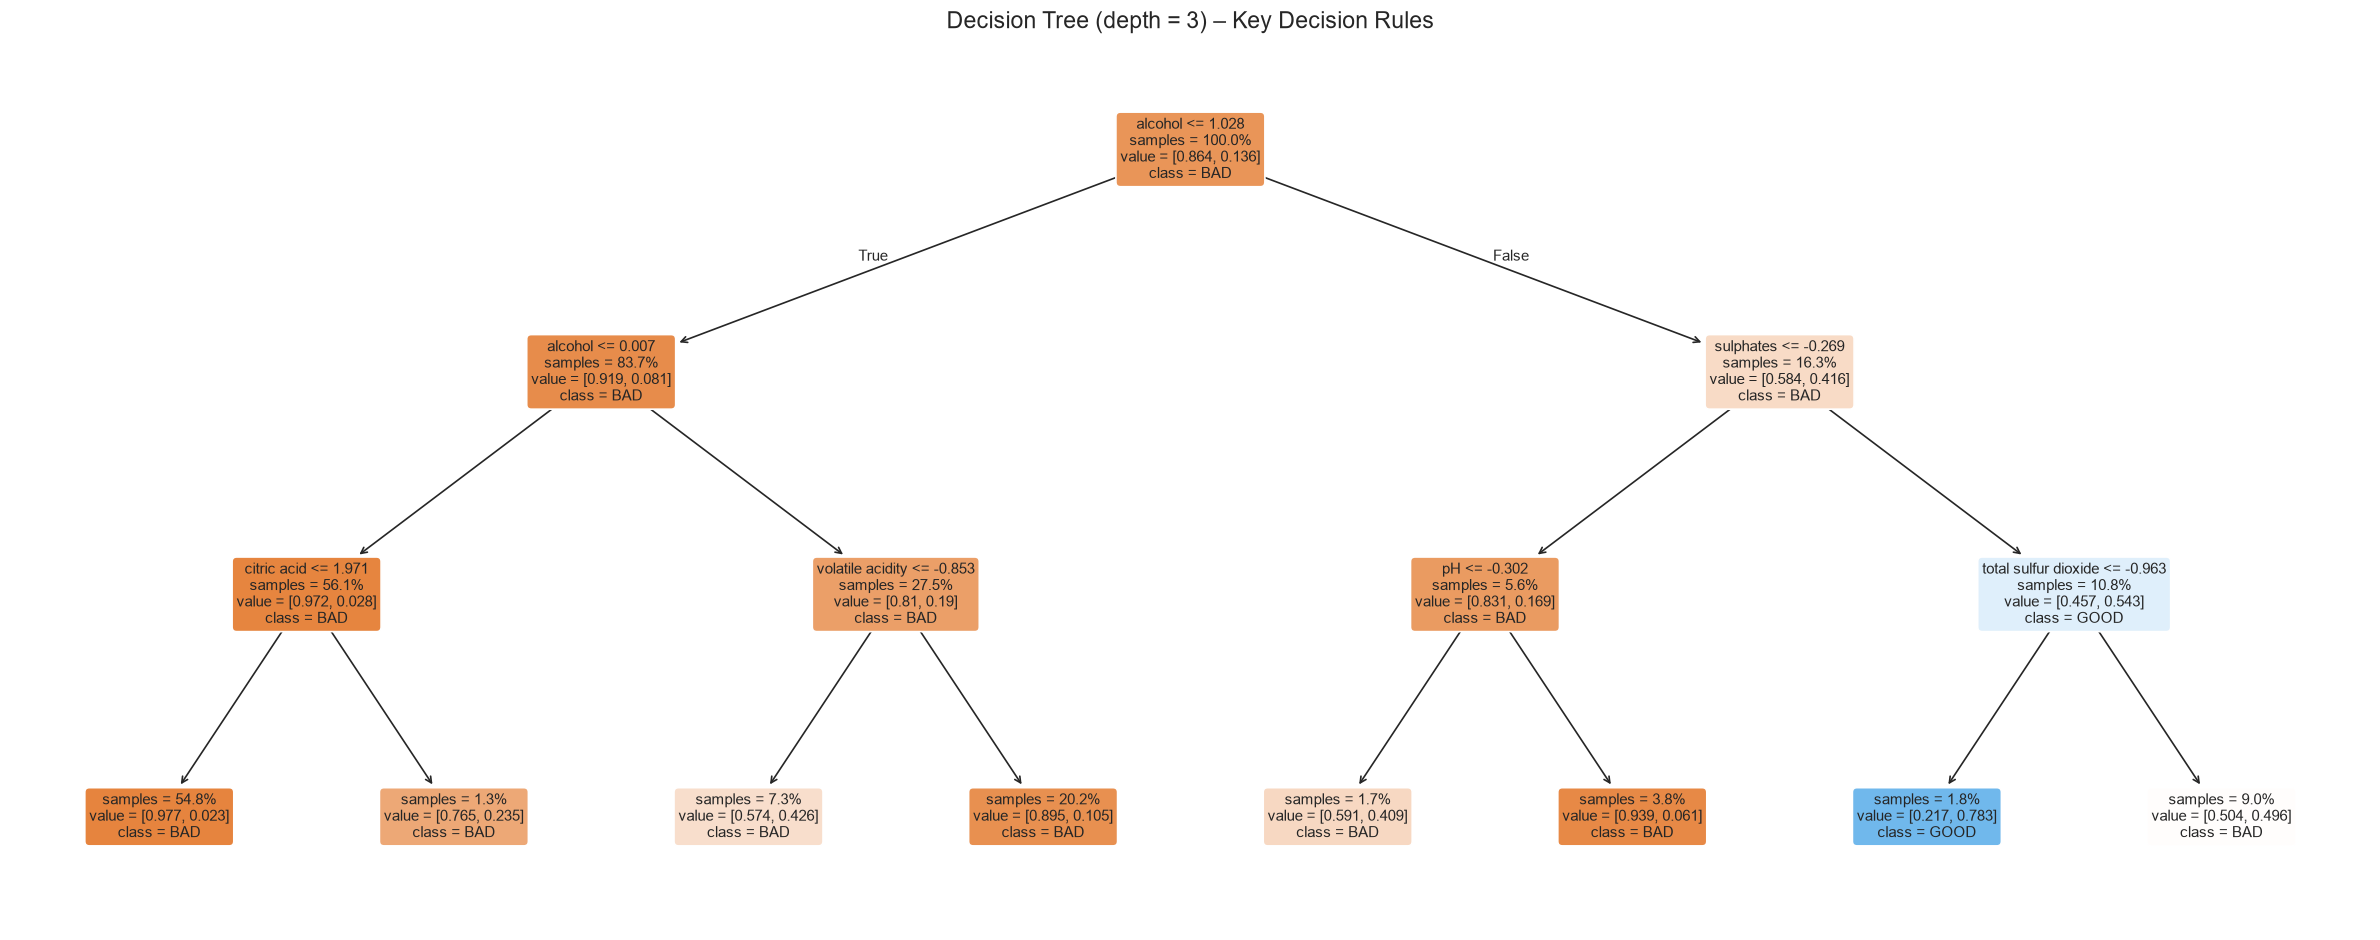

In [43]:
# Decision Tree visual (shallow tree for readability)
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train_sc, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_vis, feature_names=FEATURES,
    class_names=['BAD', 'GOOD'],
    filled=True, rounded=True,
    fontsize=9, ax=ax,
    impurity=False, proportion=True
)
ax.set_title('Decision Tree (depth = 3) – Key Decision Rules', fontsize=14)
plt.tight_layout()
plt.show()

## 12 · Final Summary Dashboard

In [44]:
summary_data = [
    res_lr_noscale,
    res_lr_scaled,
    *results,      # LR, KNN, DT on scaled
    res_tuned
]
# De-duplicate (LR scaled appears twice)
seen = set()
deduped = []
for r in summary_data:
    if r['model'] not in seen:
        deduped.append(r)
        seen.add(r['model'])

summary_df = pd.DataFrame(deduped).set_index('model')
highlight = summary_df.style\
    .background_gradient(cmap='YlGn', axis=0)\
    .format('{:.4f}')

print('\n══════════════════════════════════════════════════════════')
print('  FINAL RESULTS SUMMARY')
print('══════════════════════════════════════════════════════════')
print(summary_df.round(4).to_string())

best_overall = summary_df['f1'].idxmax()
print(f'\n🏆 Best overall model : {best_overall}')
print(f'   Accuracy  : {summary_df.loc[best_overall, "accuracy"]:.4f}')
print(f'   Precision : {summary_df.loc[best_overall, "precision"]:.4f}')
print(f'   Recall    : {summary_df.loc[best_overall, "recall"]:.4f}')
print(f'   F1-Score  : {summary_df.loc[best_overall, "f1"]:.4f}')

highlight


══════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
══════════════════════════════════════════════════════════
                                      accuracy  precision  recall      f1
model                                                                    
Logistic Regression (No Scaling)        0.8938     0.7368  0.3256  0.4516
Logistic Regression (StandardScaler)    0.8938     0.6957  0.3721  0.4848
Logistic Regression                     0.8938     0.6957  0.3721  0.4848
K-Nearest Neighbours                    0.8938     0.6667  0.4186  0.5143
Decision Tree                           0.9062     0.6383  0.6977  0.6667
Decision Tree (Tuned)                   0.9250     0.7317  0.6977  0.7143

🏆 Best overall model : Decision Tree (Tuned)
   Accuracy  : 0.9250
   Precision : 0.7317
   Recall    : 0.6977
   F1-Score  : 0.7143


,accuracy,precision,recall,f1
model,,,,
Logistic Regression (No Scaling),0.8938,0.7368,0.3256,0.4516
Logistic Regression (StandardScaler),0.8938,0.6957,0.3721,0.4848
Logistic Regression,0.8938,0.6957,0.3721,0.4848
K-Nearest Neighbours,0.8938,0.6667,0.4186,0.5143
Decision Tree,0.9062,0.6383,0.6977,0.6667
Decision Tree (Tuned),0.9250,0.7317,0.6977,0.7143


---
## 📝 Key Takeaways

| Observation | Detail |
|---|---|
| **Class imbalance** | ~86% BAD vs ~14% GOOD – Precision/Recall/F1 matter more than raw accuracy |
| **Effect of scaling** | StandardScaler typically improves Logistic Regression convergence and performance |
| **Best raw features** | `alcohol` (positive), `volatile acidity` (negative) consistently top the importance charts |
| **Hyperparameter tuning** | GridSearchCV + 5-fold CV helps squeeze out extra F1 without overfitting |
| **Model recommendation** | Decision Tree or tuned LR tend to win; ensemble methods (Random Forest, XGBoost) would likely improve further |

### Possible Next Steps
- Handle class imbalance with **SMOTE** or `class_weight='balanced'`
- Try **Random Forest** or **XGBoost** for better ensemble performance
- Use **SHAP** for explainable feature importance
- Experiment with **polynomial features** for non-linear relationships